In [1]:
import pandas as pd
from funciones_estadisticos import *

In [2]:
book_submissions, book_comments = separar_dataframes('completo_books.json')
jobs_submissions, jobs_comments = separar_dataframes('completo_jobs.json')
lol_submissions, lol_comments = separar_dataframes('completo_LeagueOfLegends.json')
random_submissions, random_comments = separar_dataframes('completo_RandomThoughts.json')
travel_submissions, travel_comments = separar_dataframes('completo_travel.json')
unpopular_submissions, unpopular_comments = separar_dataframes('completo_unpopularopinion.json')

lista_dataframes = [book_submissions, book_comments, jobs_submissions, jobs_comments, lol_submissions, lol_comments,
					random_submissions, random_comments, travel_submissions, travel_comments, unpopular_submissions, unpopular_comments]

lista_dataframes_comentarios = [book_comments, jobs_comments, lol_comments, random_comments, travel_comments, unpopular_comments]

display(book_submissions.head())
display(book_comments.head())

,author,created_utc,id,name,num_comments,score,selftext,subreddit,title,created_datetime,id_hilo_limpio
0,ekalmusLA,1.742063e+09,1jc1ngq,t3_1jc1ngq,198,1,"There, I said it. \n\nIf people have vision pr...",books,Audiobooks Count As Reading,2025-03-15T18:27:39+00:00,0
1,breadnbed,1.741975e+09,1jba710,t3_1jba710,223,390,Currently listening to a series and they switc...,books,I've come to the realisation that I'm a snobby...,2025-03-14T18:03:25+00:00,1
2,dioscurideux,1.743452e+09,1jocx8x,t3_1jocx8x,737,1031,I recently finished reading/listening to Octav...,books,Does anyone regret reading a book?,2025-03-31T20:14:59+00:00,2
3,everybeateverybreath,1.737629e+09,1i80op8,t3_1i80op8,212,121,Just curious what my fellow readers opinions a...,books,What is your opinion on authors breaking the “...,2025-01-23T10:46:29+00:00,3
4,zsreport,1.736598e+09,1hyuplb,t3_1hyuplb,314,2285,,books,"In a new book, Brooke Shields opens up about a...",2025-01-11T12:18:48+00:00,4


,author,body,controversiality,created_utc,id,link_id,parent_id,score,subreddit,created_datetime
0,Wilegar,You're preaching to the choir,1,1.742064e+09,mhymwx6,t3_1jc1ngq,t3_1jc1ngq,-2,books,2025-03-15T18:37:08+00:00
1,dawgfan19881,Does listening to the radio count as reading? ...,0,1.742064e+09,mhyog03,t3_1jc1ngq,t3_1jc1ngq,19,books,2025-03-15T18:45:09+00:00
2,Faithful_jewel,I refer to them as audiobooks and bookbooks wh...,1,1.742064e+09,mhynf3q,t3_1jc1ngq,t3_1jc1ngq,1,books,2025-03-15T18:39:44+00:00
3,PunyParker826,Are there many people who are saying otherwise?,0,1.742064e+09,mhynjw0,t3_1jc1ngq,t3_1jc1ngq,-2,books,2025-03-15T18:40:27+00:00
4,FLIPSIDERNICK,I call it A/V reading. Both are acts of readi...,0,1.742064e+09,mhynpmy,t3_1jc1ngq,t3_1jc1ngq,-4,books,2025-03-15T18:41:17+00:00


In [3]:
histograma(lista_dataframes)

In [4]:
lista_dataframes_metricas = metricas_a_df(lista_dataframes_comentarios, 'body')

metricas_generales = calcular_estadisticos_corpus(lista_dataframes_metricas)

Calculando métricas para 1180 filas de r/books...
Calculando métricas para 1180 filas de r/jobs...
Calculando métricas para 1180 filas de r/leagueoflegends...
Calculando métricas para 1180 filas de r/RandomThoughts...
Calculando métricas para 1180 filas de r/travel...
Calculando métricas para 1180 filas de r/unpopularopinion...
✅ ¡Todas las métricas calculadas!


In [5]:
display(metricas_generales)

,Subreddit,Comentarios,Total Palabras,Total Tokens,Media Palabras/Coment.,Media Frases/Coment.,Riqueza Léxica Media (TTR %)
0,r/books,1180,45783,54188,38.80,2.73,87.36
1,r/jobs,1180,40932,47713,34.69,2.72,88.98
2,r/travel,1180,40674,47460,34.47,2.67,88.66
3,r/unpopularopinion,1180,35453,41101,30.04,2.26,89.66
4,r/leagueoflegends,1180,32142,36394,27.24,1.86,91.44
5,r/RandomThoughts,1180,21852,25690,18.52,1.71,92.53


In [6]:
metricas = ['palabras','frases','palabras_por_frase','ttr']
for i in range(len(metricas)):
	boxplot(lista_dataframes_metricas, metrica=metricas[i])

In [7]:
lista_dfs_sin_bots = [df[df['author'].str.lower() != 'automoderator'] for df in lista_dataframes]
plot_top_ngramas(lista_dfs_sin_bots, n=2, top_k=15, columna_texto='body')

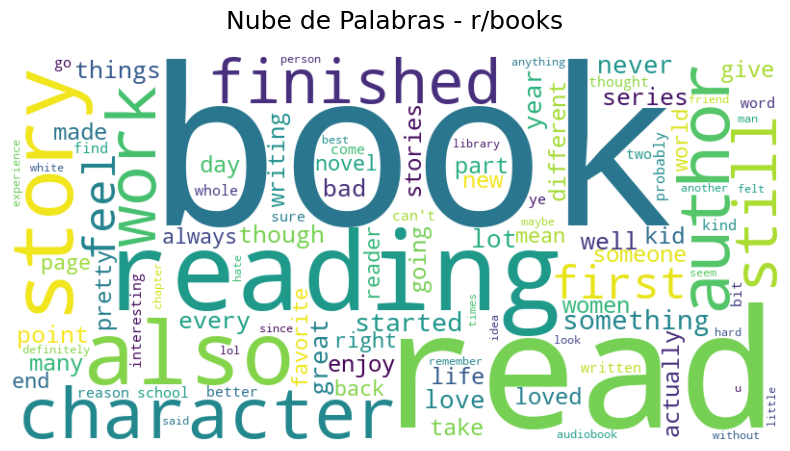

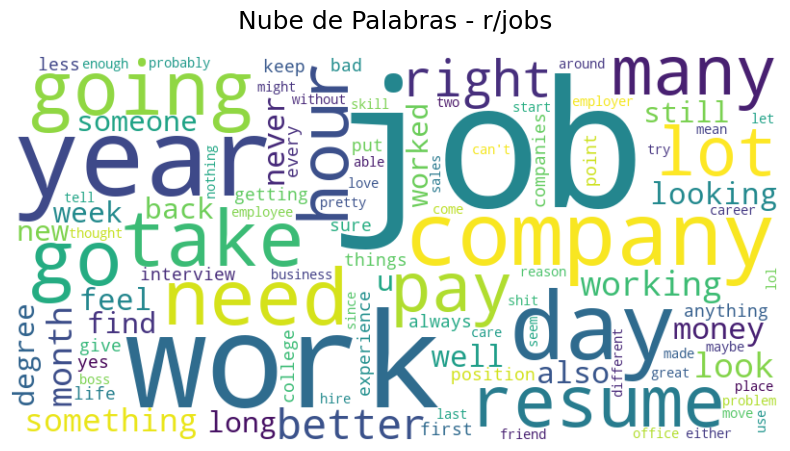

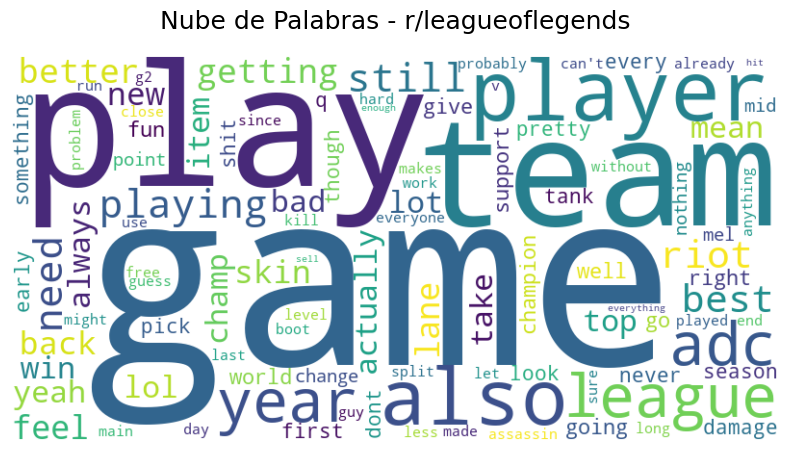

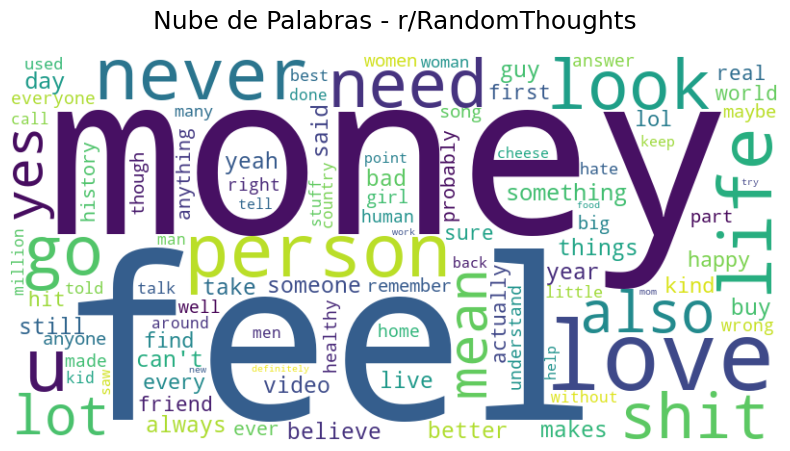

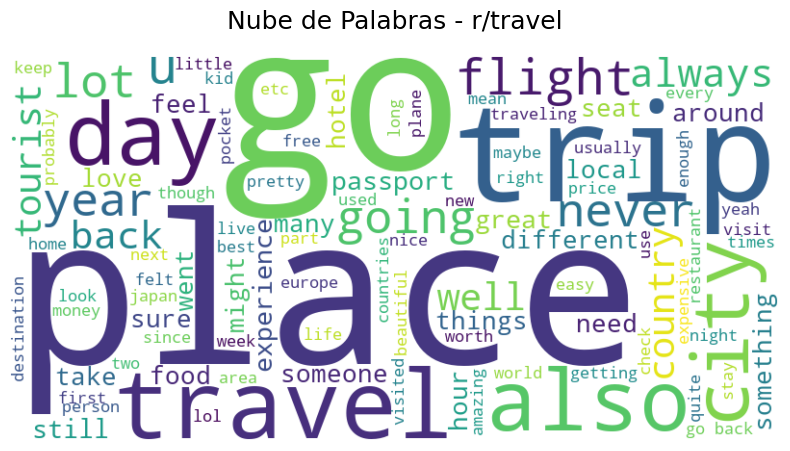

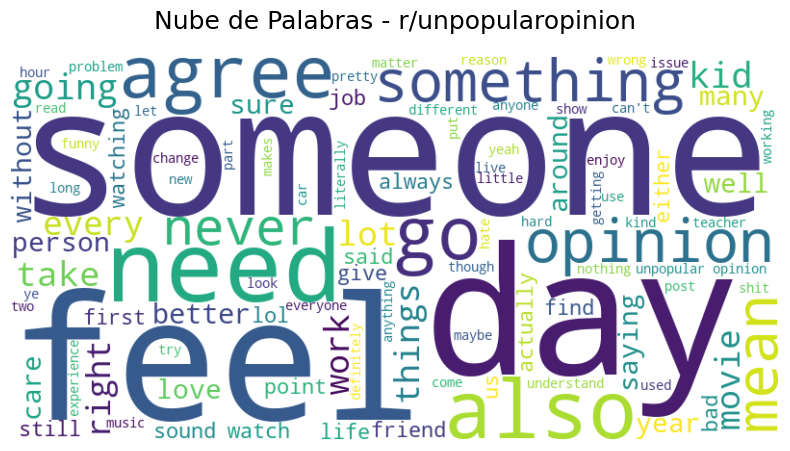

In [8]:
plot_wordclouds(lista_dfs_sin_bots, columna_texto='body')

In [9]:
plot_scatter_longitud_score(lista_dataframes_metricas, columna_longitud='palabras')

In [10]:
from langdetect import detect
import re

diccionario_idiomas = {
	'en': 'Inglés',
	'es': 'Español',
	'fr': 'Francés',
	'de': 'Alemán',
	'it': 'Italiano'
}
def deteccion_segura(texto):
	if not texto or not re.search('[a-zA-Z]', str(texto)):
		return 'unknown'
	
	try:
		return detect(texto)
	except:
		return 'unknown'

for df in lista_dataframes:
	if 'body' in df.columns:
		df['language_code'] = df['body'].apply(deteccion_segura)
		df['language'] = df['language_code'].apply(lambda x: diccionario_idiomas.get(x, 'Otro') if isinstance(x, str) and len(x) > 0 else 'unknown')
	else:
		df['language_code'] = df['title'].apply(deteccion_segura)
		df['language'] = df['language_code'].apply(lambda x: diccionario_idiomas.get(x, 'Otro') if isinstance(x, str) and len(x) > 0 else 'unknown')

plot_pie(lista_dataframes, columna='language', titulo='Distribucion de Idiomas en el Corpus')

<Figure size 800x800 with 0 Axes>

In [11]:
barplot(lista_dfs_sin_bots)